# Deutschlandticket Commute Attractiveness 
## J&J Medical GmbH, Norderstedt

**Question:** For employees commuting to Robert-Koch-Straße 1, 22851 Norderstedt,
how good is public transport, and how likely would they be to switch to the
Deutschlandticket?

Since real employee addresses can't be used, we simulate a synthetic workforce spread
across Hamburg and nearby towns, then estimate each person's public-transport
door-to-door time and a simple adoption-likelihood score.

**Steps:** synthetic data → nearest station → commute time → time-bands →
adoption score → summary → (optional) map.

*Everything below is deliberately kept to one clear formula per step, so it's easy to
explain and easy to adjust later with real HVV journey-planner data.*

## 1. Setup

In [112]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Initialize the geocoder only once
geolocator = Nominatim(user_agent='employee_geocoder')

geocode = RateLimiter(
    geolocator.geocode, min_delay_seconds=1, max_retries=3, error_wait_seconds=5
)

# J&J Medical GmbH Address
address = 'Robert-Koch-Str. 1, Norderstedt'

location = geocode(address)
if location:
    WORKPLACE = {
        "name": "J&J Medical GmbH", 
        "lat": location.latitude, 
        "lon": location.longitude
    } 
    
WORKPLACE

{'name': 'J&J Medical GmbH', 'lat': 53.6865222, 'lon': 10.0469639}

## 2. Synthetic employee dataset

10 representative home areas across Hamburg + the surrounding commuter belt, each with
a rough coordinate and a sampling weight (more employees close to Norderstedt / bigger
districts, fewer in small outlying towns). Each employee gets a small random offset
around their area so addresses aren't all identical.

*No real employee data is used anywhere — everything below is generated.*

#### Haversine formula (6371 = Radius of Earth in Km)
The Haversine formula calculates the shortest distance between two geographic locations based on their latitude and longitude. It accounts for the Earth's curvature, providing an accurate distance in kilometers or miles. In this dataset, it is used to estimate the distance from each employee's home to the workplace.

$$
a = \sin^2\left(\frac{\Delta\phi}{2}\right)
+ \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)
$$

$$
d = 2R\arcsin\left(\sqrt{a}\right)
$$

In [113]:
import numpy as np

# name, lat, lon, weight
AREAS = [
    ("Norderstedt",        53.6975, 10.0111, 20),
    ("Langenhorn",         53.6608, 9.9814,  14),
    ("Alsterdorf/Ohlsdorf",53.6150, 10.0120, 12),
    ("Eppendorf/Winterhude",53.5930, 9.9980, 12),
    ("Eimsbüttel",         53.5786, 9.9636,  10),
    ("Hamburg-Innenstadt", 53.5511, 9.9937,  10),
    ("Quickborn",          53.7361, 9.9092,  8),
    ("Henstedt-Ulzburg / Kaltenkirchen", 53.8100, 9.9650, 8),
    ("Ahrensburg",         53.6742, 10.2378, 6),
    ("Pinneberg",          53.6626, 9.7961,  6),
]

# Haversine Formula to calculate distance
def haversine_km(lat1, lon1, lat2, lon2):
    # Mapping Coord from Degree to Radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * 6371 * np.arcsin(np.sqrt(a))          

In [115]:
import pandas as pd

SEED = 42
N_EMPLOYEES = 400

# Initialize a random number generator with a fixed seed
rng = np.random.default_rng(SEED)
names, lats, lons, weights = zip(*AREAS)

# Convert the area weights into selection probabilities
probs = np.array(weights) / sum(weights)

# Randomly assign each employee to a residential area based on the defined probabilities
idx = rng.choice(len(AREAS), size=N_EMPLOYEES, p=probs)

jitter = 0.01  # ~1km scatter so employees aren't stacked on one point

employees = pd.DataFrame({
    "employee_id": [f"EMP{i:04d}" for i in range(1, N_EMPLOYEES + 1)],
    "home_area": [names[i] for i in idx],
    "home_lat": np.array([lats[i] for i in idx]) + rng.normal(0, jitter, N_EMPLOYEES),
    "home_lon": np.array([lons[i] for i in idx]) + rng.normal(0, jitter, N_EMPLOYEES),
    "has_car": rng.random(N_EMPLOYEES) < 0.5,
    "environmental_attitude": np.clip(rng.normal(50, 20, N_EMPLOYEES), 0, 100).round(0),
})
employees["distance_to_workplace_km"] = haversine_km(
    employees["home_lat"], 
    employees["home_lon"], 
    WORKPLACE["lat"],
    WORKPLACE["lon"]
).round(1)

employees.head()

,employee_id,home_area,home_lat,home_lon,has_car,environmental_attitude,distance_to_workplace_km
0,EMP0001,Quickborn,53.740496,9.909642,False,61.0,10.8
1,EMP0002,Eppendorf/Winterhude,53.598242,9.995971,False,36.0,10.4
2,EMP0003,Henstedt-Ulzburg / Kaltenkirchen,53.812763,9.954176,True,48.0,15.3
3,EMP0004,Hamburg-Innenstadt,53.536972,9.992189,False,18.0,17.0
4,EMP0005,Norderstedt,53.674399,10.003639,True,3.0,3.2


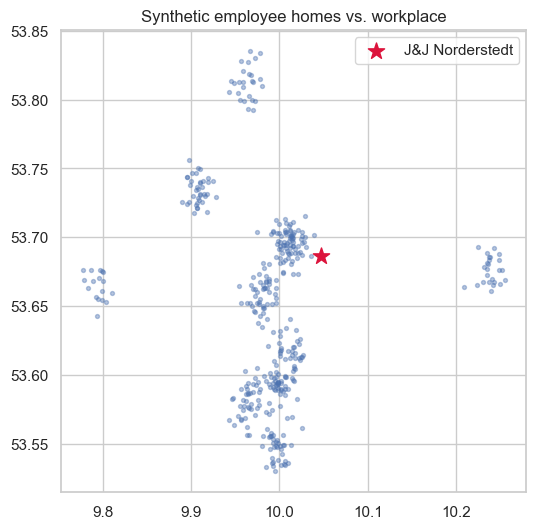

In [116]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(employees["home_lon"], employees["home_lat"], s=8, alpha=0.4)
ax.scatter([WORKPLACE["lon"]], [WORKPLACE["lat"]], s=150, marker="*", color="crimson", label="J&J Norderstedt")
ax.set_title("Synthetic employee homes vs. workplace")
ax.legend()
plt.savefig('../figures/Synthetic employee homes vs. workplace.png')
plt.show()

## 3. Nearest public-transport station

A short list of well-known real stations covering the main corridor into Norderstedt
(the U1 line) plus a couple of feeder points for people further out. Each employee is
matched to their closest one (straight-line distance).

We tag each station's **mode**: `Rail` (U-/S-Bahn/AKN — faster, more frequent) or
`Bus` (slower, less frequent). That's the only distinction we make — good enough to
separate "well connected" from "poorly connected" without a full network model.

In [117]:
# name, mode, lat, lon
STATIONS = [
    ("Norderstedt Mitte", "Rail", 53.6975, 10.0111),
    ("Ochsenzoll",        "Rail", 53.6822, 9.9931),
    ("Langenhorn Nord",   "Rail", 53.6631, 9.9819),
    ("Ohlsdorf",          "Rail", 53.6316, 10.0143),
    ("Kellinghusenstraße","Rail", 53.5872, 9.9853),
    ("Jungfernstieg",     "Rail", 53.5528, 9.9931),
    ("Eidelstedt",        "Rail", 53.6019, 9.9147),
    ("Poppenbüttel",      "Rail", 53.6499, 10.0761),
    ("Quickborn (AKN)",   "Rail", 53.7361, 9.9092),
    ("Ahrensburg",        "Rail", 53.6742, 10.2378),
    ("Pinneberg",         "Rail", 53.6626, 9.7961),
    ("Kaltenkirchen (AKN)","Rail", 53.8386, 9.9614),
]

# Create a DataFrame containing all station information
stations = pd.DataFrame(STATIONS, columns=["station", "mode", "lat", "lon"])

# Function to find the nearest station to a given latitude and longitude
def nearest(lat, lon):
    
    # Calculate the distance from the given location to every station
    d = haversine_km(lat, lon, stations["lat"].values, stations["lon"].values)
    j = d.argmin()
    
    return stations["station"][j], stations["mode"][j], round(d[j], 2)

In [118]:
# Determine the nearest station for every employee and store the results

employees[["nearest_station", "station_mode", "dist_to_station_km"]] = (
    employees.apply(lambda r: nearest(r["home_lat"], r["home_lon"]), axis=1, result_type="expand")
)

# Simple, explainable connection quality: 
# Good / Medium / Poor
def connection_quality(mode, dist_km):
    if mode == "Rail" and dist_km <= 1.0:
        return "Good"
    if dist_km <= 2.0:
        return "Medium"
    return "Poor"

employees["connection_quality"] = employees.apply(
    lambda r: connection_quality(r["station_mode"], r["dist_to_station_km"]), axis=1
)

employees[["home_area", "nearest_station", "station_mode", "dist_to_station_km", "connection_quality"]].head()

,home_area,nearest_station,station_mode,dist_to_station_km,connection_quality
0,Quickborn,Quickborn (AKN),Rail,0.49,Good
1,Eppendorf/Winterhude,Kellinghusenstraße,Rail,1.42,Medium
2,Henstedt-Ulzburg / Kaltenkirchen,Kaltenkirchen (AKN),Rail,2.91,Poor
3,Hamburg-Innenstadt,Jungfernstieg,Rail,1.76,Medium
4,Norderstedt,Ochsenzoll,Rail,1.11,Medium


## 4. Door-to-door commute time

One simple formula, four parts:

$$\text{door-to-door} = \underbrace{\text{walk to station}}_{4.5\ \text{km/h}} + \underbrace{\text{wait}}_{\text{fixed}} + \underbrace{\text{ride to Norderstedt}}_{\text{Rail }30\text{, Bus }18\ \text{km/h}} + \underbrace{\text{walk to office}}_{10\ \text{min fixed}}$$

- Wait time: 15 min for Rail (frequent), 12 min for Bus (less frequent).
- Ride distance: straight-line distance from the station to the workplace, ×1.2 to
  roughly account for the route not being perfectly straight.

*(Simplification: we don't model line changes/transfers, and we cap the walk-to-station
leg at 3km — beyond that we assume some form of feeder transport rather than a very
long walk. Both are reasonable first-pass simplifications, flagged as next steps.)*

In [119]:
WALK_SPEED = 4.5   # average human walking speed
SPEED = {"Rail": 30, "Bus": 18}   # km/h
WAIT = {"Rail": 15, "Bus": 12}    # minutes
Walk_To_Office = 10  # Fixed

# distance from each station to the workplace (used for the "ride" leg)
stations["dist_to_workplace_km"] = haversine_km(
    stations["lat"], stations["lon"], WORKPLACE["lat"], WORKPLACE["lon"]
)

# Create a dictionary that maps each station name to its distance to the workplace
station_to_wp = dict(zip(stations["station"], stations["dist_to_workplace_km"]))

# Calculate walking time from each employee's home to their nearest station
# Formula: time = distance / walking speed * 60 minutes
employees["walk_to_station_min"] = (employees["dist_to_station_km"].clip(upper=2.0) / WALK_SPEED * 60).round(1)

# Calculate waiting time for public transport. Waiting time is randomly generated for realistic variation between employees
employees["wait_min"] = employees["station_mode"].apply(lambda x: rng.uniform(0, WAIT[x])).round(1)

# Calculate travel time from the nearest station to the workplace
# Multiply by 1.2 to account for the fact that real routes are not perfectly straight
employees["ride_min"] = (
    employees["nearest_station"].map(station_to_wp) * 1.2 / employees["station_mode"].map(SPEED) * 60
).round(1)

# Calculate total door-to-door commute time:
employees["door_to_door_min"] = (
    employees["walk_to_station_min"] + employees["wait_min"] + employees["ride_min"] + LAST_MILE_MIN
).round(1)

employees[["employee_id", "home_area", "nearest_station", "walk_to_station_min",
           "wait_min", "ride_min", "door_to_door_min"]].head()

,employee_id,home_area,nearest_station,walk_to_station_min,wait_min,ride_min,door_to_door_min
0,EMP0001,Quickborn,Quickborn (AKN),6.5,5.7,25.5,47.7
1,EMP0002,Eppendorf/Winterhude,Kellinghusenstraße,18.9,8.0,28.2,65.1
2,EMP0003,Henstedt-Ulzburg / Kaltenkirchen,Kaltenkirchen (AKN),26.7,8.9,42.8,88.4
3,EMP0004,Hamburg-Innenstadt,Jungfernstieg,23.5,0.3,36.7,70.5
4,EMP0005,Norderstedt,Ochsenzoll,14.8,7.7,8.6,41.1


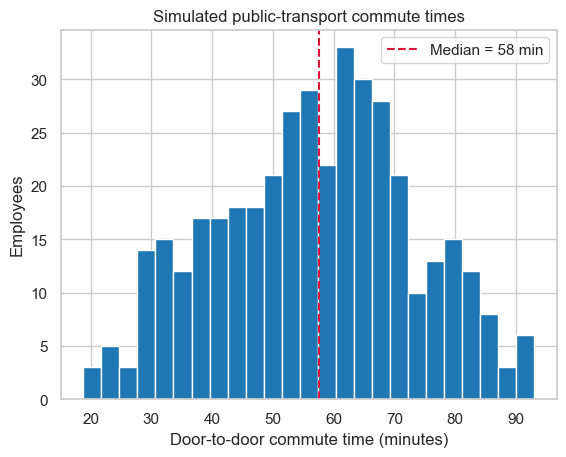

In [120]:
fig, ax = plt.subplots()
ax.hist(employees["door_to_door_min"], bins=25, color="#1f77b4", edgecolor="white")
ax.axvline(employees["door_to_door_min"].median(), color="crimson", linestyle="--",
           label=f"Median = {employees['door_to_door_min'].median():.0f} min")
ax.set_xlabel("Door-to-door commute time (minutes)")
ax.set_ylabel("Employees")
ax.set_title("Simulated public-transport commute times")
ax.legend()
plt.savefig('../figures/Simulated public-transport commute times.png')
plt.show()

## 5. Commute-time grouping (≤30 / ≤45 / ≤60 / >60 minutes)

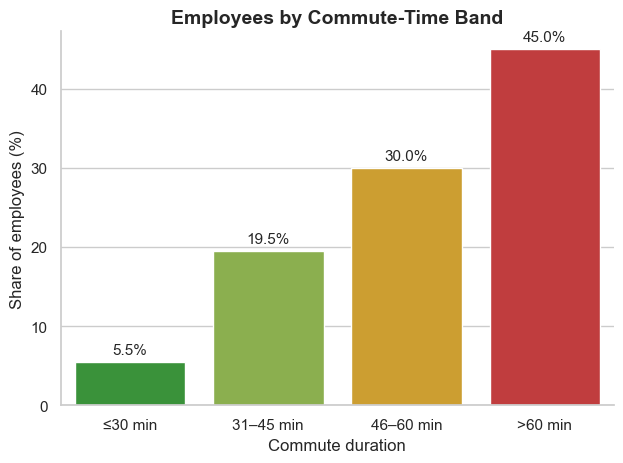

commute_band
≤30 min       5.5
31–45 min    19.5
46–60 min    30.0
>60 min      45.0
Name: share_of_employees_%, dtype: float64

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create commute time categories
bins = [0, 30, 45, 60, np.inf]
labels = ["≤30 min", "31–45 min", "46–60 min", ">60 min"]

employees["commute_band"] = pd.cut(
    employees["door_to_door_min"], 
    bins=bins, 
    labels=labels
)

# Calculate percentage of employees in each category
band = (
    employees["commute_band"]
    .value_counts(normalize=True)
    .reindex(labels)
    .fillna(0)
    .mul(100)
    .round(1)
)

# Plot
sns.set_style("whitegrid")

ax = sns.barplot(
    x=band.index,
    y=band.values,
    hue=band.index,
    palette=["#2ca02c", "#8fbf3f", "#e6a817", "#d62728"],
    legend=False
)

# Add percentage labels
for i, value in enumerate(band.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center", fontsize=11)

# Formatting
ax.set_title("Employees by Commute-Time Band", fontsize=14, weight="bold")
ax.set_xlabel("Commute duration")
ax.set_ylabel("Share of employees (%)")

sns.despine()
plt.tight_layout()
plt.savefig('../figures/Employees by Commute-Time Band.png')
plt.show()

band.rename("share_of_employees_%")

## 6. Deutschlandticket adoption score

A simple weighted score (0–100), three ingredients:

- **Time score (50%)** — shorter commute → higher score (drops off past ~45 min)
- **Sustainability attitude (30%)** — the employee's own environmental-attitude value
- **Cost-saving appeal (20%)** — longer car-distance commutes save more by switching

Employees who already own a car get a flat −10 (more inertia to switching).
Score is then bucketed into **Low / Medium / High** adoption potential.

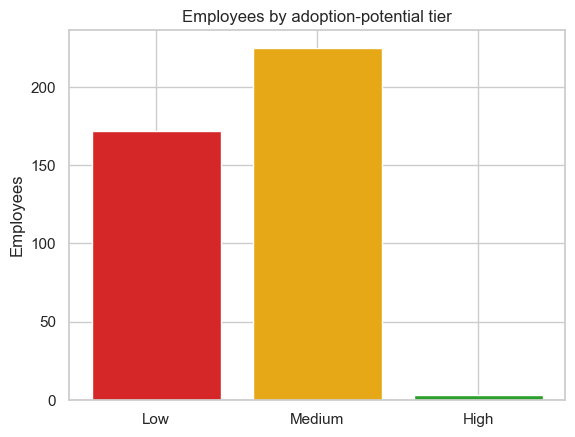

,employee_id,door_to_door_min,environmental_attitude,adoption_score,adoption_tier
0,EMP0001,47.7,61.0,58.9,Medium
1,EMP0002,65.1,36.0,39.8,Low
2,EMP0003,88.4,48.0,22.2,Low
3,EMP0004,70.5,18.0,36.2,Low
4,EMP0005,41.1,3.0,29.7,Low


In [146]:
time_score = np.clip(100 - (employees["door_to_door_min"] - 20) * 1.3, 0, 100)
cost_score = np.clip(employees["distance_to_workplace_km"] * 4, 0, 100)

employees["adoption_score"] = (
    0.5 * time_score + 0.3 * employees["environmental_attitude"] + 0.2 * cost_score
    - employees["has_car"].astype(int) * 10
).clip(0, 100).round(1)

employees["adoption_tier"] = pd.cut(
    employees["adoption_score"], bins=[-1, 40, 70, 101], labels=["Low", "Medium", "High"]
)

fig, ax = plt.subplots()
tier_counts = employees["adoption_tier"].value_counts().reindex(["Low", "Medium", "High"])
ax.bar(tier_counts.index, tier_counts.values, color=["#d62728", "#e6a817", "#2ca02c"])
ax.set_title("Employees by adoption-potential tier")
ax.set_ylabel("Employees")
plt.show()

employees[["employee_id", "door_to_door_min", "environmental_attitude", "adoption_score", "adoption_tier"]].head()

## 7. Quick sanity checks & key factors

Instead of a full ML pipeline (overkill for this scope), two lightweight checks:

1. **Sanity checks** — commute times and scores fall in plausible ranges, no negative
   values, bands sum to 100%.
2. **What drives the adoption score?** — simple correlations, since the score is a
   transparent formula anyway; this just confirms it behaves as intended and gives a
   one-line "key factors" answer for the summary.

Sanity checks passed:
  Commute time range: 19-93 min
  Adoption score range: 9-72


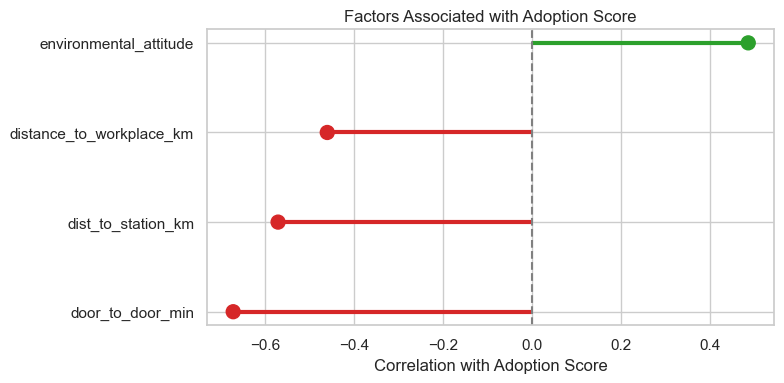

In [158]:
# -----------------------------
# 1. Sanity checks
# -----------------------------

assert employees["door_to_door_min"].min() > 0, "Commute time should never be negative/zero"
assert employees["adoption_score"].between(0, 100).all(), "Score should stay within 0-100"

assert abs(band.sum()) == 100, "Commute-time bands should sum to ~100%"

print("Sanity checks passed:")

print(f"  Commute time range: {employees['door_to_door_min'].min():.0f}-{employees['door_to_door_min'].max():.0f} min")
print(f"  Adoption score range: {employees['adoption_score'].min():.0f}-{employees['adoption_score'].max():.0f}")

# -----------------------------
# 2. Correlation analysis
# -----------------------------

# Select the variables to compare with the adoption score
factors = ["door_to_door_min", "dist_to_station_km", "distance_to_workplace_km", "environmental_attitude"]

# Remove the self-correlation (adoption_score = 1.0) and sort the results
corr = (
    employees[factors + ["adoption_score"]]
    .corr()["adoption_score"]
    .drop("adoption_score")
    .sort_values()
)

# -----------------------------
# 3. Visualise correlations
# -----------------------------

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in corr.values]

# Create a horizontal line chart of the correlation coefficients
ax.hlines(y=corr.index, xmin=0, xmax=corr.values,
          color=colors, linewidth=3)
ax.scatter(corr.values, corr.index,
           color=colors, s=100)

ax.axvline(0, color="gray", linestyle="--")
ax.set_xlabel("Correlation with Adoption Score")
ax.set_title("Factors Associated with Adoption Score")

plt.tight_layout()
plt.savefig('../figures/Correlation of each factor with adoption score.png')
plt.show()

## 8. Final summary

In [159]:
print("=" * 60)
print("DEUTSCHLANDTICKET COMMUTE ATTRACTIVENESS — SUMMARY")
print(f"Workplace: J&J Medical GmbH, Robert-Koch-Straße 1, Norderstedt")
print(f"Synthetic employees analysed: {len(employees)}")
print("=" * 60)

print("\n1) Commute-time bands")
for label, pct in band.items():
    print(f"   {label:>10}: {pct:5.1f}%")

print("\n2) Adoption potential")
tier_pct = (employees["adoption_tier"].value_counts(normalize=True).reindex(["High", "Medium", "Low"]) * 100).round(1)
for tier, pct in tier_pct.items():
    print(f"   {tier:>6}: {pct:5.1f}%")
print(f"   Mean adoption score: {employees['adoption_score'].mean():.1f}/100")

area_stats = employees.groupby("home_area").agg(
    avg_commute_min=("door_to_door_min", "mean"),
    avg_adoption_score=("adoption_score", "mean"),
).round(1).sort_values("avg_commute_min")

print("\n3) Best-connected areas")
print(area_stats.head(3).to_string())
print("\n4) Least-attractive areas")
print(area_stats.tail(3).to_string())

print("\n5) Key factors (strongest correlations with adoption score)")
for feat, val in corr.reindex(corr.abs().sort_values(ascending=False).index).items():
    print(f"   {feat:<28} r = {val:+.2f}")
print("=" * 60)

employees.to_csv("../data/synthetic_employee_commute_dataset.csv", index=False)

DEUTSCHLANDTICKET COMMUTE ATTRACTIVENESS — SUMMARY
Workplace: J&J Medical GmbH, Robert-Koch-Straße 1, Norderstedt
Synthetic employees analysed: 400

1) Commute-time bands
      ≤30 min:   5.5%
    31–45 min:  19.5%
    46–60 min:  30.0%
      >60 min:  45.0%

2) Adoption potential
     High:   0.8%
   Medium:  56.2%
      Low:  43.0%
   Mean adoption score: 42.5/100

3) Best-connected areas
                     avg_commute_min  avg_adoption_score
home_area                                               
Norderstedt                     36.9                49.7
Langenhorn                      45.3                47.0
Alsterdorf/Ohlsdorf             54.7                43.1

4) Least-attractive areas
                                  avg_commute_min  avg_adoption_score
home_area                                                            
Eimsbüttel                                   69.3                36.9
Pinneberg                                    70.4                40.3
Henstedt-Ulzbu

## 9. Optional — interactive map

In [163]:
import folium

# -----------------------------
# 1. Create the base map
# -----------------------------
m = folium.Map(location=[53.62, 9.98], zoom_start=10, tiles="cartodbpositron")

# -----------------------------
# 2. Add the workplace location
# -----------------------------
folium.Marker([WORKPLACE["lat"], WORKPLACE["lon"]], popup=WORKPLACE["name"],
              icon=folium.Icon(color="red", icon="briefcase", prefix="fa")).add_to(m)

# -----------------------------
# 3. Add public transport stations
# -----------------------------

for _, s in stations.iterrows():
    folium.CircleMarker([s["lat"], s["lon"]], radius=4, color="#444", fill=True,
                         popup=f"{s['station']} ({s['mode']})").add_to(m)

# -----------------------------
# 4. Plot employee home locations
# -----------------------------

# Assign colours based on adoption-potential tier.

tier_color = {
    "High": "green", 
    "Medium": "orange", 
    "Low": "red"
}

# Plot each employee's home location.

for _, e in employees.iterrows():
    folium.CircleMarker(
        [e["home_lat"], e["home_lon"]], radius=3, color=tier_color[e["adoption_tier"]],
        fill=True, fill_opacity=0.7,
        popup=f"{e['employee_id']} | {e['door_to_door_min']:.0f} min | {e['adoption_tier']}",
    ).add_to(m)

m.save("../figures/commute_map.html")
m

---
### Assumptions, in one place
- Coordinates (workplace, stations, areas) are approximate, not survey-grade.
- Commute time = walk + wait + ride + fixed last-mile; no transfers modelled.
- Two speed/wait tiers only: Rail vs. Bus.
- Adoption score is a transparent weighted formula (time, environmental attitude,
  cost-saving appeal, car ownership) — not a trained model, so it's easy to defend
  and easy to re-weight.
- All employee data is synthetic.